In [1]:
import pandas as pd

def print_results(task, model, benchmark, experiment_type, isLargeGraphs, isImproved=False):
    if isLargeGraphs:
        filepath = f"./{task}/large_graphs/{model}/results_{task}_{benchmark}_{experiment_type}.csv"
    else:
        filepath = f"./{task}/{model}/results_{task}_{benchmark}_{experiment_type}.csv"
    
    if isImproved:
        filepath = f"./{task}/improved/{model}/results_{task}_{benchmark}_{experiment_type}.csv"
        
    df = pd.read_csv(filepath)

    print("\n" + "="*100)
    print(f"SETUP → Task: {task} | Model: {model} | Benchmark: {benchmark} | "
          f"Experiment: {experiment_type} | LargeGraphs: {isLargeGraphs}")
    print(f"File: {filepath}")
    print("="*100)
    
    if isImproved: 
        layouts = ["FMMM", "IMPROVED"]
    else:
        layouts = ["FMMM", "ORTHO"]
        
    reasoning_types = df["reasoning_type"].unique()
    prompt_types = df["prompt_type"].unique()

    for rtype in reasoning_types:

        # Skip SOAL when not relevant
        if rtype == 'soal' and experiment_type in ['mixed', 'textual']:
            continue

        print(f"\n> Reasoning type: {rtype}")

        if experiment_type in ["mixed", "visual"]:

            for layout in layouts:
                print(f"  > Layout: {layout}")

                for ptype in prompt_types:
                    print(f"    > Prompt type: {ptype}")

                    subset = df[
                        (df["reasoning_type"] == rtype) &
                        (df["layout"] == layout) &
                        (df["prompt_type"] == ptype)
                    ]

                    if len(subset) == 0:
                        print("      (No entries)")
                        continue

                    print(
                        f"        Accuracy       : {subset['accuracy'].mean():.2f}\n"
                        f"        Latency        : {subset['latency'].mean():.2f}\n"
                        f"        Input Tokens   : {subset['input_tokens'].mean():.2f}\n"
                        f"        Output Tokens  : {subset['output_tokens'].mean():.2f}\n"
                        f"        Total Tokens   : {subset['total_tokens'].mean():.2f}"
                    )

        else:
            for ptype in prompt_types:
                print(f"  > Prompt type: {ptype}")

                subset = df[
                    (df["reasoning_type"] == rtype) &
                    (df["prompt_type"] == ptype)
                ]

                if len(subset) == 0:
                    print("    (No entries)")
                    continue

                print(
                    f"    Accuracy       : {subset['accuracy'].mean():.2f}\n"
                    f"    Latency        : {subset['latency'].mean():.2f}\n"
                    f"    Input Tokens   : {subset['input_tokens'].mean():.2f}\n"
                    f"    Output Tokens  : {subset['output_tokens'].mean():.2f}\n"
                    f"    Total Tokens   : {subset['total_tokens'].mean():.2f}"
                )


# Large Graphs

In [3]:
tasks = ['common_neighbours', 'shortest_path']
models = ['gpt', 'claude', 'llama']
benchmarks = ['large_graphs']
experiment_types = ['textual', 'visual',  'mixed']
isLargeGraphs=True

for task in tasks:
    for model in models:
        for benchmark in benchmarks:
            for experiment_type in experiment_types:
                print_results(task, model, benchmark, experiment_type, True)
        print('\n')


SETUP → Task: common_neighbours | Model: gpt | Benchmark: large_graphs | Experiment: textual | LargeGraphs: True
File: ./common_neighbours/large_graphs/gpt/results_common_neighbours_large_graphs_textual.csv

> Reasoning type: standard
  > Prompt type: zero_shot
    Accuracy       : 0.33
    Latency        : 1.29
    Input Tokens   : 2074.00
    Output Tokens  : 15.83
    Total Tokens   : 2089.83
  > Prompt type: few_shots
    Accuracy       : 0.38
    Latency        : 0.89
    Input Tokens   : 2532.00
    Output Tokens  : 12.00
    Total Tokens   : 2544.00

> Reasoning type: cot
  > Prompt type: zero_shot
    Accuracy       : 1.00
    Latency        : 4.01
    Input Tokens   : 2122.00
    Output Tokens  : 267.17
    Total Tokens   : 2389.17
  > Prompt type: few_shots
    Accuracy       : 0.96
    Latency        : 4.00
    Input Tokens   : 2738.00
    Output Tokens  : 244.00
    Total Tokens   : 2982.00

SETUP → Task: common_neighbours | Model: gpt | Benchmark: large_graphs | Experimen

- Plot of the latency for different reasoning type of GPT

In [13]:
task='shortest_path'
benchmark='large_graphs'
model='gpt'
experiment_type='visual'

filepath=f"./{task}/large_graphs/{model}/results_{task}_{benchmark}_{experiment_type}.csv"
df = pd.read_csv(filepath)
df.head(3)

,graph,layout,parameters,prompt_type,reasoning_type,response,parsed_response,ground_truth,accuracy,latency,input_tokens,output_tokens,total_tokens
0,ba_n100_m2,FMMM,"{'start_node': '85', 'end_node': '21'}",zero_shot,standard,"Path: 85, 42, 7, 21, Length: 3","{'path': ['85', '42', '7', '21'], 'length': 3}","{'path': ['85', '27', '9', '21'], 'length': 3}",0.00,4.482544,965,18,983
1,ba_n100_m2,FMMM,"{'start_node': '85', 'end_node': '21'}",zero_shot,cot,To find the shortest path between nodes 85 and...,"{'path': ['85', '42', '13', '3', '5', '21'], '...","{'path': ['85', '27', '9', '21'], 'length': 3}",0.12,19.965634,1026,518,1544
2,ba_n100_m2,FMMM,"{'start_node': '85', 'end_node': '21'}",zero_shot,soal,To find the shortest path between nodes 85 and...,"{'path': ['85', '38', '33', '5', '21'], 'lengt...","{'path': ['85', '27', '9', '21'], 'length': 3}",0.00,77.008406,1047,2339,3386


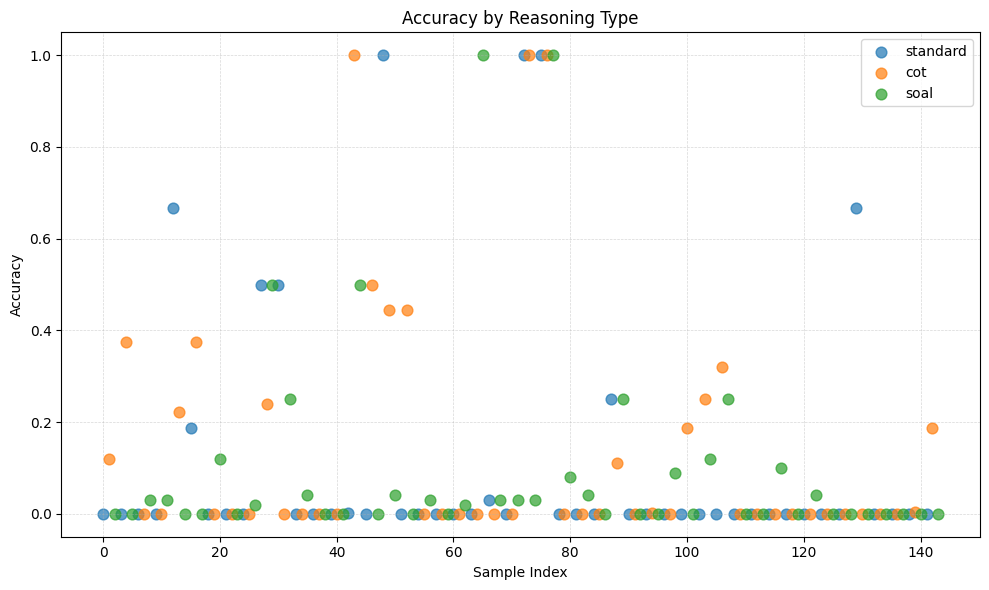

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

for r in df["reasoning_type"].unique():
    subset = df[df["reasoning_type"] == r]
    plt.scatter(
        subset.index,
        subset["accuracy"],
        label=r,
        alpha=0.7,           # transparency helps when dense
        s=60                 # slightly larger markers
    )

plt.xlabel("Sample Index")
plt.ylabel("Accuracy")
plt.title("Accuracy by Reasoning Type")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)  # light grey grid
plt.legend()
plt.tight_layout()
plt.show()


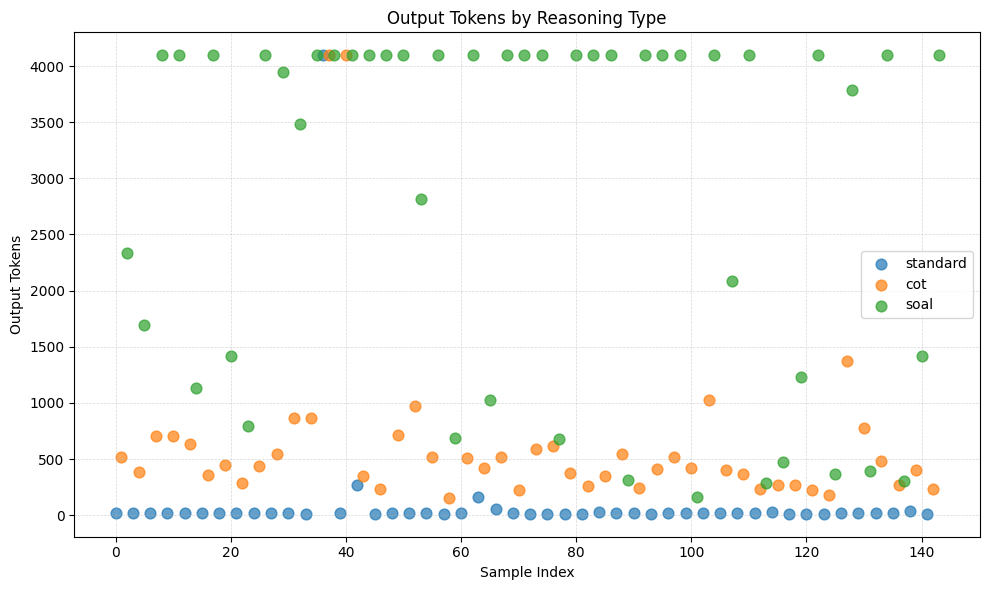

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

for r in df["reasoning_type"].unique():
    subset = df[df["reasoning_type"] == r]
    plt.scatter(
        subset.index,
        subset["output_tokens"],
        label=r,
        alpha=0.7,           # transparency helps when dense
        s=60                 # slightly larger markers
    )

plt.xlabel("Sample Index")
plt.ylabel("Output Tokens")
plt.title("Output Tokens by Reasoning Type")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)  # light grey grid
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
total = len(df)/3

result = (
    df[df["output_tokens"] == 4096]
    .groupby("reasoning_type")
    .size()
    .rename("count")
)

result = result.to_frame()
result["percentage"] = (result["count"] / total) * 100

print(result)


                count  percentage
reasoning_type                   
cot                 2    4.166667
soal               26   54.166667
standard            1    2.083333


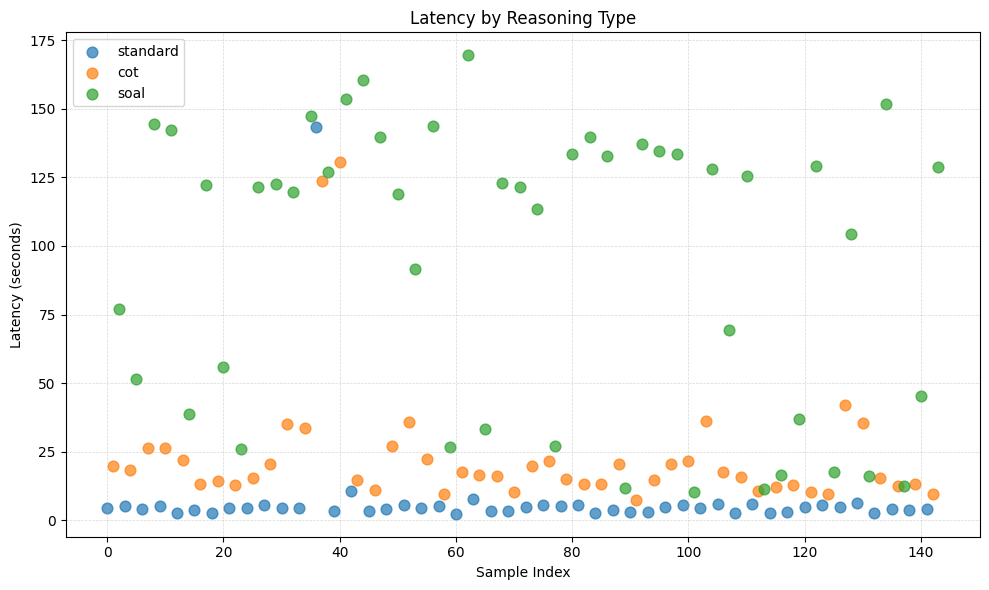

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

for r in df["reasoning_type"].unique():
    subset = df[df["reasoning_type"] == r]
    plt.scatter(
        subset.index,
        subset["latency"],
        label=r,
        alpha=0.7,           # transparency helps when dense
        s=60                 # slightly larger markers
    )

plt.xlabel("Sample Index")
plt.ylabel("Latency (seconds)")
plt.title("Latency by Reasoning Type")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)  # light grey grid
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
t = 2000/60
print(f'Minutes: {t:.2f}')
t = 1500/60
print(f'Minutes: {t:.2f}')
t = 1000/60
print(f'Minutes: {t:.2f}')

Minutes: 33.33
Minutes: 25.00
Minutes: 16.67


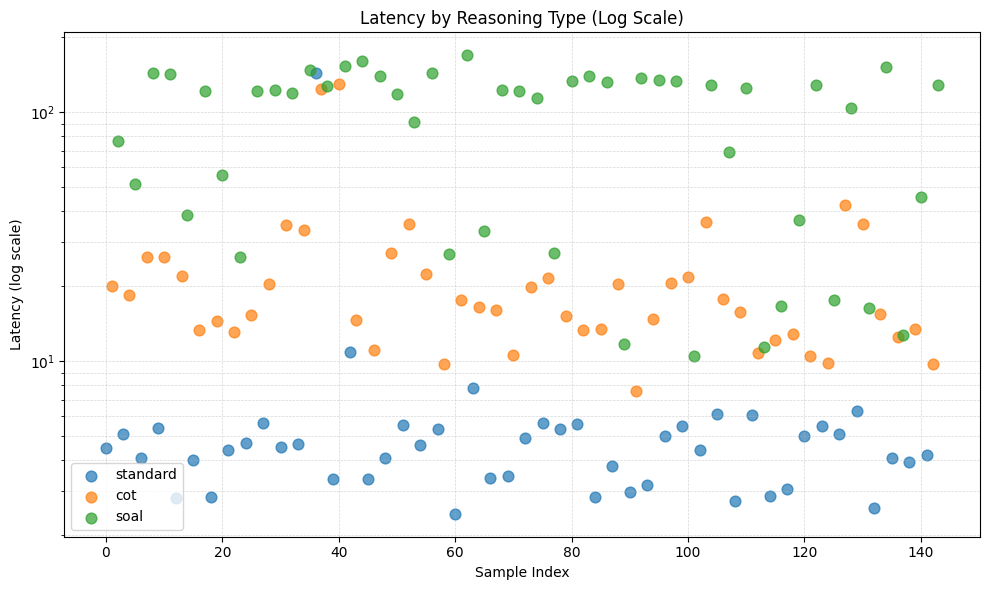

In [18]:
plt.figure(figsize=(10,6))

for r in df["reasoning_type"].unique():
    subset = df[df["reasoning_type"] == r]
    plt.scatter(
        subset.index,
        subset["latency"],
        label=r,
        alpha=0.7,
        s=60
    )

plt.yscale("log")      
plt.xlabel("Sample Index")
plt.ylabel("Latency (log scale)")
plt.title("Latency by Reasoning Type (Log Scale)")

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# LLAMA

## Common Neighbours and Shortest Path

In [32]:
tasks = ['common_neighbours', 'shortest_path']
models = ['llama']
benchmarks = ['general']
experiment_types = ['textual', 'visual', 'mixed']
isLargeGraphs=False

for task in tasks:
    for model in models:
        for benchmark in benchmarks:
            for experiment_type in experiment_types:
                
                print_results(task, model, benchmark, experiment_type, isLargeGraphs)
        print('\n')


SETUP → Task: common_neighbours | Model: llama | Benchmark: general | Experiment: textual | LargeGraphs: False
File: ./common_neighbours/llama/results_common_neighbours_general_textual.csv

> Reasoning type: standard
  > Prompt type: zero_shot
    Accuracy       : 0.88
    Latency        : 0.77
    Input Tokens   : 316.80
    Output Tokens  : 16.25
    Total Tokens   : 333.05
  > Prompt type: few_shots
    Accuracy       : 0.93
    Latency        : 0.68
    Input Tokens   : 769.80
    Output Tokens  : 88.08
    Total Tokens   : 857.88

> Reasoning type: cot
  > Prompt type: zero_shot
    Accuracy       : 1.00
    Latency        : 1.47
    Input Tokens   : 361.80
    Output Tokens  : 345.60
    Total Tokens   : 707.40
  > Prompt type: few_shots
    Accuracy       : 1.00
    Latency        : 0.99
    Input Tokens   : 972.80
    Output Tokens  : 192.05
    Total Tokens   : 1164.85

SETUP → Task: common_neighbours | Model: llama | Benchmark: general | Experiment: visual | LargeGraphs: Fal

In [2]:
tasks = ['shortest_path']
models = ['llama']
benchmarks = ['improved_drawings']
experiment_types = ['visual', 'mixed']
isLargeGraphs=False

for task in tasks:
    for model in models:
        for benchmark in benchmarks:
            for experiment_type in experiment_types:
                
                print_results(task, model, benchmark, experiment_type, isLargeGraphs, isImproved=True)
        print('\n')


SETUP → Task: shortest_path | Model: llama | Benchmark: improved_drawings | Experiment: visual | LargeGraphs: False
File: ./shortest_path/improved/llama/results_shortest_path_improved_drawings_visual.csv

> Reasoning type: standard
  > Layout: FMMM
    > Prompt type: zero_shot
        Accuracy       : 0.37
        Latency        : 1.74
        Input Tokens   : 2280.46
        Output Tokens  : 30.12
        Total Tokens   : 2310.59
    > Prompt type: few_shots
        Accuracy       : 0.40
        Latency        : 1.70
        Input Tokens   : 6622.29
        Output Tokens  : 24.48
        Total Tokens   : 6646.77
  > Layout: IMPROVED
    > Prompt type: zero_shot
        Accuracy       : 0.41
        Latency        : 1.31
        Input Tokens   : 2323.79
        Output Tokens  : 33.89
        Total Tokens   : 2357.68
    > Prompt type: few_shots
        Accuracy       : 0.44
        Latency        : 1.44
        Input Tokens   : 6663.71
        Output Tokens  : 25.07
        Total Toke

In [4]:
tasks = ['max_clique']
models = ['llama']
benchmarks = ['clique']
experiment_types = ['textual', 'visual', 'mixed']
isLargeGraphs=False

for task in tasks:
    for model in models:
        for benchmark in benchmarks:
            for experiment_type in experiment_types:
                
                
                print_results(task, model, benchmark, experiment_type, isLargeGraphs)
        print('\n')


SETUP → Task: max_clique | Model: llama | Benchmark: clique | Experiment: textual | LargeGraphs: False
File: ./max_clique/llama/results_max_clique_clique_textual.csv

> Reasoning type: standard
  > Prompt type: zero_shot
    Accuracy       : 0.80
    Latency        : 1.63
    Input Tokens   : 273.30
    Output Tokens  : 198.20
    Total Tokens   : 471.50
  > Prompt type: few_shots
    Accuracy       : 0.84
    Latency        : 1.84
    Input Tokens   : 523.30
    Output Tokens  : 465.40
    Total Tokens   : 988.70

> Reasoning type: cot
  > Prompt type: zero_shot
    Accuracy       : 0.90
    Latency        : 3.78
    Input Tokens   : 353.30
    Output Tokens  : 1084.65
    Total Tokens   : 1437.95
  > Prompt type: few_shots
    Accuracy       : 0.90
    Latency        : 3.21
    Input Tokens   : 1085.30
    Output Tokens  : 901.05
    Total Tokens   : 1986.35

SETUP → Task: max_clique | Model: llama | Benchmark: clique | Experiment: visual | LargeGraphs: False
File: ./max_clique/llam

In [5]:
tasks = ['min_vertex_cover']
models = ['llama']
benchmarks = ['vertex_cover']
experiment_types = ['textual', 'visual', 'mixed']
isLargeGraphs=False

for task in tasks:
    for model in models:
        for benchmark in benchmarks:
            for experiment_type in experiment_types:
                
                print_results(task, model, benchmark, experiment_type, isLargeGraphs)
        print('\n')


SETUP → Task: min_vertex_cover | Model: llama | Benchmark: vertex_cover | Experiment: textual | LargeGraphs: False
File: ./min_vertex_cover/llama/results_min_vertex_cover_vertex_cover_textual.csv

> Reasoning type: standard
  > Prompt type: zero_shot
    Accuracy       : 0.75
    Latency        : 5.37
    Input Tokens   : 319.50
    Output Tokens  : 1208.35
    Total Tokens   : 1527.85
  > Prompt type: few_shots
    Accuracy       : 0.61
    Latency        : 3.52
    Input Tokens   : 512.50
    Output Tokens  : 794.25
    Total Tokens   : 1306.75

> Reasoning type: cot
  > Prompt type: zero_shot
    Accuracy       : 0.78
    Latency        : 5.40
    Input Tokens   : 400.50
    Output Tokens  : 1371.05
    Total Tokens   : 1771.55
  > Prompt type: few_shots
    Accuracy       : 0.73
    Latency        : 6.08
    Input Tokens   : 1067.50
    Output Tokens  : 1565.30
    Total Tokens   : 2632.80

SETUP → Task: min_vertex_cover | Model: llama | Benchmark: vertex_cover | Experiment: visua